# Zebrafish Survival Analysis

This notebook provides interactive analysis and visualization tools for exploring zebrafish survival data from the MetaZebrobot system.

## Setup and Data Loading

First, let's import the libraries we'll need:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import Button, VBox, HBox, Label, Output

# Functions

In [175]:
def extract_records_with_old_dpf(csv_file, min_dpf=15, output_file=None):
    """
    Extract and return all records where days post-fertilization (dpf) exceeds a threshold.
    
    Parameters:
    -----------
    csv_file : str
        Path to the CSV file containing the survival data
    min_dpf : int
        Minimum days post-fertilization threshold (default: 15)
    output_file : str, optional
        If provided, saves the filtered results to this CSV file
        
    Returns:
    --------
    DataFrame containing only records where days_since_fertilization >= min_dpf
    """
    # Load the CSV file
    print(f"Loading data from {csv_file}...")
    df = pd.read_csv(csv_file)
    
    # Check if the days_since_fertilization column exists
    if 'days_since_fertilization' not in df.columns:
        print("Error: 'days_since_fertilization' column not found in the data.")
        return None
    
    # Filter for records where dpf >= min_dpf
    old_records = df[df['days_since_fertilization'] >= min_dpf].copy()
    
    # Print summary
    print(f"\nFound {len(old_records)} records where days post-fertilization >= {min_dpf}")
    print(f"These records come from {old_records['dish_id'].nunique()} unique dishes")
    
    # List the unique dish IDs
    print("\nUnique dish IDs with old dpf records:")
    for dish_id in sorted(old_records['dish_id'].unique()):
        count = len(old_records[old_records['dish_id'] == dish_id])
        print(f"  - {dish_id}: {count} records")
    
    # Save to output file if specified
    if output_file:
        old_records.to_csv(output_file, index=False)
        print(f"\nSaved filtered records to {output_file}")
    
    return old_records

# Function to convert YYYYMMDD format to datetime
def convert_date(date_val):
    if pd.isna(date_val) or date_val == 0:
        return pd.NaT
    
    date_str = str(int(date_val))
    if len(date_str) != 8:
        return pd.NaT
    
    try:
        return pd.to_datetime(date_str, format='%Y%m%d')
    except:
        return pd.NaT

def calculate_survival_derivatives(df):
    # First, ensure the dataframe is sorted properly
    # We need to sort by dish_id and days_since_fertilization
    df_sorted = df.sort_values(['dish_id', 'days_since_fertilization'])
    
    # Create a copy to avoid modifying the original dataframe
    df_with_derivatives = df_sorted.copy()
    
    # Create a groupby object by dish_id
    grouped = df_with_derivatives.groupby('dish_id')
    
    # Lists to store the results
    all_dish_ids = []
    all_days = []
    all_derivatives = []
    
    # Calculate derivatives for each dish
    for dish_id, group in grouped:
        # Only calculate derivative if we have more than one observation
        if len(group) > 1:
            # Calculate day-to-day change in survival rate
            derivatives = group['survival_rate'].diff() / group['days_since_fertilization'].diff()
            
            # Store the results
            all_dish_ids.extend([dish_id] * len(derivatives))
            all_days.extend(group['days_since_fertilization'].tolist())
            all_derivatives.extend(derivatives.tolist())
    
    # Create a new dataframe with the derivatives
    derivative_df = pd.DataFrame({
        'dish_id': all_dish_ids,
        'days_since_fertilization': all_days,
        'survival_rate_change': all_derivatives
    })
    
    # Merge back to the original dataframe
    df_with_derivatives = pd.merge(
        df_sorted, 
        derivative_df,
        on=['dish_id', 'days_since_fertilization'],
        how='left'
    )
    
    return df_with_derivatives

In [218]:
def calculate_density(df):
    """
    Calculate fish density metrics and categorize based on volume per fish
    """
    # Create a copy to avoid warnings
    result_df = df.copy()
    
    # Calculate density if both columns exist
    if 'initial_count' in df.columns and 'vol_water_total' in df.columns:
        # Ensure values are numeric
        result_df['initial_count'] = pd.to_numeric(result_df['initial_count'], errors='coerce')
        result_df['vol_water_total'] = pd.to_numeric(result_df['vol_water_total'], errors='coerce')
        
        # Calculate both density metrics
        result_df['fish_density'] = result_df['initial_count'] / result_df['vol_water_total']  # fish per mL
        result_df['volume_per_fish'] = result_df['vol_water_total'] / result_df['initial_count']  # mL per fish
        
        # Create density categories based on volume per fish (mL/fish)
        result_df['density_category'] = pd.cut(
            result_df['volume_per_fish'],
            bins=[0, 2, 3, 4, np.inf],
            labels=['Very High (<2mL/fish)', 'High (2-3mL/fish)', 'Medium (3-4mL/fish)', 
                   'Low (>4mL/fish)']
        )
    else:
        # Add empty columns if needed
        result_df['fish_density'] = np.nan
        result_df['volume_per_fish'] = np.nan
        result_df['density_category'] = None
        
    return result_df

def create_comprehensive_visualization(df):
    """Create a comprehensive visualization with all plot types"""
    # Calculate density metrics
    df_with_density = calculate_density(df)
    
    # Create output for displaying plots
    output = Output()
    
    # Create buttons for plot types
    genotype_btn = Button(description="Survival by Genotype", button_style='primary')
    density_btn = Button(description="Survival by Density", button_style='')
    scatter_btn = Button(description="Density vs Survival", button_style='')
    housing_btn = Button(description="Beaker vs Dish", button_style='')
    
    # Row of buttons
    plot_buttons = HBox([genotype_btn, density_btn, scatter_btn, housing_btn])

    # Container for sub-options
    sub_options_container = VBox([])
    
    # Visibility state for conditions
    visibility_state = {}
    
    # Create container for condition toggle buttons
    condition_buttons_container = VBox([Label(value="")])
    
    # Function to update button styles
    def update_button_styles(selected_btn):
        for btn in [genotype_btn, density_btn, scatter_btn]:
            btn.button_style = 'primary' if btn == selected_btn else ''
    
    # Function to create condition toggle buttons based on active plot type
    def create_condition_toggles():
        # Clear existing buttons
        condition_buttons_container.children = [Label(value="Toggle Groups:")]
        
        # Determine which conditions to show based on the current plot type
        if genotype_btn.button_style == 'primary':
            # Get genotype/housing combinations
            if 'in_beaker' in df_with_density.columns:
                conditions = []
                for genotype in sorted(df_with_density['genotype'].unique()):
                    beaker_conditions = df_with_density[df_with_density['genotype'] == genotype]['in_beaker'].unique()
                    for is_beaker in beaker_conditions:
                        housing = "beaker" if str(is_beaker).lower() in ['true', 't', 'yes', 'y', '1'] else "dish"
                        conditions.append(f"{genotype} ({housing})")
            else:
                conditions = sorted(df_with_density['genotype'].unique())
                
        elif density_btn.button_style == 'primary':
            # Get density categories
            conditions = sorted(df_with_density['density_category'].dropna().unique())
            
        elif scatter_btn.button_style == 'primary':
            # For scatter plot, show genotypes
            conditions = sorted(df_with_density['genotype'].unique())
        else:
            # For histogram, no condition toggles needed
            condition_buttons_container.children = [Label(value="")]
            return
        
        # Create toggle button for each condition
        buttons = []
        for condition in conditions:
            # Initialize visibility state if not already set
            if condition not in visibility_state:
                visibility_state[condition] = True
                
            # Create the toggle button
            btn = Button(
                description=str(condition),
                button_style='success' if visibility_state[condition] else '',
                layout={'width': 'auto'}
            )
            
            # Store reference to condition in the button
            btn.condition = condition
            
            # Define click handler
            def toggle_condition(b):
                # Toggle visibility state
                visibility_state[b.condition] = not visibility_state[b.condition]
                
                # Update button style
                b.button_style = 'success' if visibility_state[b.condition] else ''
                
                # Update plot
                update_plot()
            
            # Attach click handler
            btn.on_click(toggle_condition)
            buttons.append(btn)
        
        # Add buttons to container in rows of 3
        row = []
        for i, btn in enumerate(buttons):
            row.append(btn)
            if (i + 1) % 3 == 0 or i == len(buttons) - 1:
                condition_buttons_container.children = (*condition_buttons_container.children, HBox(row))
                row = []
    
    # Function to update plot based on current settings
    def update_plot():
        with output:
            clear_output(wait=True)
            
            if genotype_btn.button_style == 'primary':
                # Show by genotype
                fig = plot_survival_curves(df_with_density, color_by_density=False, 
                                          visible_conditions=visibility_state)
                display(fig)
            elif density_btn.button_style == 'primary':
                # Show by density
                fig = plot_survival_curves(df_with_density, color_by_density=True,
                                          visible_conditions=visibility_state)
                display(fig)
            elif scatter_btn.button_style == 'primary':
                # Show scatter plot
                fig = plot_density_vs_survival(df_with_density, use_volume_per_fish=True,
                                              visible_conditions=visibility_state)
                display(fig)
    
    # Button handlers for plot type selection
    def on_genotype_btn_clicked(b):
        update_button_styles(genotype_btn)
        sub_options_container.children = []
        create_condition_toggles()
        update_plot()
    
    def on_density_btn_clicked(b):
        update_button_styles(density_btn)
        sub_options_container.children = []
        create_condition_toggles()
        update_plot()
    
    def on_scatter_btn_clicked(b):
        update_button_styles(scatter_btn)
        sub_options_container.children = []
        create_condition_toggles()
        update_plot()
    
    def on_housing_btn_clicked(b):  # New handler
        update_button_styles(housing_btn)
        sub_options_container.children = []
        # No toggles needed for this plot
        condition_buttons_container.children = [Label(value="")]
        update_plot()
    
    # Connect button handlers
    genotype_btn.on_click(on_genotype_btn_clicked)
    density_btn.on_click(on_density_btn_clicked)
    scatter_btn.on_click(on_scatter_btn_clicked)
    housing_btn.on_click(on_housing_btn_clicked)  # Connect new handler
    
    # Function to update button styles
    def update_button_styles(selected_btn):
        for btn in [genotype_btn, density_btn, scatter_btn, housing_btn]:  # Added housing_btn
            btn.button_style = 'primary' if btn == selected_btn else ''
    
    # Function to update plot based on current settings
    def update_plot():
        with output:
            clear_output(wait=True)
            
            if genotype_btn.button_style == 'primary':
                # Show by genotype
                fig = plot_survival_curves(df_with_density, color_by_density=False, 
                                          visible_conditions=visibility_state)
                display(fig)
            elif density_btn.button_style == 'primary':
                # Show by density
                fig = plot_survival_curves(df_with_density, color_by_density=True,
                                          visible_conditions=visibility_state)
                display(fig)
            elif scatter_btn.button_style == 'primary':
                # Show scatter plot
                fig = plot_density_vs_survival(df_with_density, use_volume_per_fish=True,
                                              visible_conditions=visibility_state)
                display(fig)
            elif housing_btn.button_style == 'primary':
                # Show housing comparison
                fig = plot_housing_comparison(df_with_density)
                display(fig)
    # Layout
    controls_left = VBox([
        Label(value="Select Plot Type:"), 
        plot_buttons, 
        sub_options_container
    ])
    controls_right = condition_buttons_container
    controls = HBox([controls_left, controls_right])
    app = VBox([controls, output])
    
    return app

def plot_survival_curves(df, color_by_density=False, visible_conditions=None):
    """Plot survival curves over time"""
    # Make a copy of the dataframe
    plot_df = df.copy()
    
    # Create a plotly figure
    if color_by_density and 'density_category' in plot_df.columns:
        fig = px.line(
            plot_df, 
            x='days_since_fertilization', 
            y='survival_rate', 
            color='density_category',
            line_group='dish_id',
            hover_data=['dish_id', 'genotype', 'initial_count', 'volume_per_fish', 'vol_water_total'],
            labels={
                'days_since_fertilization': 'Days Since Fertilization',
                'survival_rate': 'Survival Rate (%)',
                'density_category': 'Fish Density',
                'volume_per_fish': 'Volume per Fish (mL/fish)'
            },
            title='Survival Curves by Fish Density',
            color_discrete_sequence=px.colors.qualitative.Plotly
        )
        
        # Add mean survival curves by density category
        unique_cats = plot_df['density_category'].dropna().unique()
        if len(unique_cats) > 1:
            for cat in unique_cats:
                cat_df = plot_df[plot_df['density_category'] == cat]
                
                # Calculate means by day for this category
                day_means = cat_df.groupby('days_since_fertilization')['survival_rate'].mean().reset_index()
                
                # Add a bold mean line
                fig.add_trace(
                    go.Scatter(
                        x=day_means['days_since_fertilization'],
                        y=day_means['survival_rate'],
                        mode='lines',
                        line=dict(width=4, dash='dash'),
                        name=f'{cat} (mean)',
                        showlegend=True
                    )
                )
        
        # Apply visibility settings
        if visible_conditions:
            for i, trace in enumerate(fig.data):
                name = trace.name
                # Handle normal traces and mean traces
                if name in visible_conditions:
                    fig.data[i].visible = visible_conditions[name]
                elif name.endswith(" (mean)") and name[:-7] in visible_conditions:
                    # Also toggle the mean line with its group
                    fig.data[i].visible = visible_conditions[name[:-7]]
        
    elif 'in_beaker' in plot_df.columns:
        # Create a new column combining genotype and beaker status for color coding
        plot_df['genotype_housing'] = plot_df.apply(
            lambda row: f"{row['genotype']} (beaker)" if str(row['in_beaker']).lower() in ['true', 't', 'yes', 'y', '1'] 
            else f"{row['genotype']} (dish)", 
            axis=1
        )
        
        # Use genotype_housing for color coding
        fig = px.line(
            plot_df, 
            x='days_since_fertilization', 
            y='survival_rate', 
            color='genotype_housing',
            line_group='dish_id',
            hover_data=['dish_id', 'initial_count', 'in_beaker', 'volume_per_fish', 'vol_water_total'],
            labels={
                'days_since_fertilization': 'Days Since Fertilization',
                'survival_rate': 'Survival Rate (%)',
                'genotype_housing': 'Genotype & Housing',
                'volume_per_fish': 'Volume per Fish (mL/fish)',
                'vol_water_total': 'Water Volume (mL)'
            },
            title='Survival Curves by Genotype and Housing Type'
        )
        
        # Add mean survival curves by genotype and housing
        unique_combos = plot_df['genotype_housing'].unique()
        if len(unique_combos) > 1:
            for combo in unique_combos:
                combo_df = plot_df[plot_df['genotype_housing'] == combo]
                
                # Calculate means by day for this combination
                day_means = combo_df.groupby('days_since_fertilization')['survival_rate'].mean().reset_index()
                
                # Add a bold mean line
                fig.add_trace(
                    go.Scatter(
                        x=day_means['days_since_fertilization'],
                        y=day_means['survival_rate'],
                        mode='lines',
                        line=dict(width=4, dash='dash'),
                        name=f'{combo} (mean)',
                        showlegend=True
                    )
                )
        
        # Apply visibility settings
        if visible_conditions:
            for i, trace in enumerate(fig.data):
                name = trace.name
                # Handle normal traces and mean traces
                if name in visible_conditions:
                    fig.data[i].visible = visible_conditions[name]
                elif name.endswith(" (mean)") and name[:-7] in visible_conditions:
                    # Also toggle the mean line with its group
                    fig.data[i].visible = visible_conditions[name[:-7]]
                    
    else:
        # Fall back to original approach if in_beaker column is not available
        fig = px.line(
            plot_df, 
            x='days_since_fertilization', 
            y='survival_rate', 
            color='genotype',
            line_group='dish_id',
            hover_data=['dish_id', 'initial_count', 'volume_per_fish', 'vol_water_total'],
            labels={
                'days_since_fertilization': 'Days Since Fertilization',
                'survival_rate': 'Survival Rate (%)',
                'genotype': 'Genotype',
                'volume_per_fish': 'Volume per Fish (mL/fish)',
                'vol_water_total': 'Water Volume (mL)'
            },
            title='Survival Curves by Genotype'
        )
        
        # Add mean survival curves by genotype
        if plot_df['genotype'].nunique() > 1:
            for genotype in plot_df['genotype'].unique():
                genotype_df = plot_df[plot_df['genotype'] == genotype]
                
                # Calculate means by day for this genotype
                day_means = genotype_df.groupby('days_since_fertilization')['survival_rate'].mean().reset_index()
                
                # Add a bold mean line
                fig.add_trace(
                    go.Scatter(
                        x=day_means['days_since_fertilization'],
                        y=day_means['survival_rate'],
                        mode='lines',
                        line=dict(width=4, dash='dash'),
                        name=f'{genotype} (mean)',
                        showlegend=True
                    )
                )
                
        # Apply visibility settings
        if visible_conditions:
            for i, trace in enumerate(fig.data):
                name = trace.name
                # Handle normal traces and mean traces
                if name in visible_conditions:
                    fig.data[i].visible = visible_conditions[name]
                elif name.endswith(" (mean)") and name[:-7] in visible_conditions:
                    # Also toggle the mean line with its group
                    fig.data[i].visible = visible_conditions[name[:-7]]
    
    # Add a custom legend title
    if color_by_density:
        fig.update_layout(
            legend_title_text='Fish Density'
        )
    elif 'in_beaker' in plot_df.columns:
        fig.update_layout(
            legend_title_text='Genotype & Housing'
        )
    
    # Update layout for better appearance
    fig.update_layout(
        xaxis_title='Days Since Fertilization',
        yaxis_title='Survival Rate (%)',
        yaxis=dict(range=[0, 100]),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        hovermode='closest',
        height=600,
        width=1000
    )
    
    return fig

def plot_housing_comparison(df):
    """Compare survival rates between beaker and dish housing for each genotype"""
    # Make a copy of the dataframe
    plot_df = df.copy()
    
    # Only process if in_beaker column exists
    if 'in_beaker' not in plot_df.columns:
        return px.scatter(title="Housing comparison not available - 'in_beaker' column missing")
    
    # Create housing type column
    plot_df['housing'] = plot_df['in_beaker'].apply(
        lambda x: "Beaker" if str(x).lower() in ['true', 't', 'yes', 'y', '1'] else "Dish"
    )
    
    # For each dish, get the final survival rate
    latest_records = plot_df.loc[plot_df.groupby('dish_id')['days_since_fertilization'].idxmax()]
    
    # Calculate average final survival rate by genotype and housing
    summary = latest_records.groupby(['genotype', 'housing'])['survival_rate'].agg(
        ['mean', 'std', 'count']
    ).reset_index()
    
    # Calculate standard error
    summary['se'] = summary['std'] / np.sqrt(summary['count'])
    
    # Create bar chart
    fig = px.bar(
        summary,
        x='genotype',
        y='mean',
        color='housing',
        barmode='group',
        error_y='se',  # Add error bars
        labels={
            'mean': 'Final Survival Rate (%)',
            'genotype': 'Genotype',
            'housing': 'Housing Type'
        },
        title='Comparison of Final Survival Rates by Genotype and Housing Type'
    )
    
    # Add individual data points as markers
    for housing_type in ['Beaker', 'Dish']:
        housing_data = latest_records[latest_records['housing'] == housing_type]
        
        fig.add_trace(
            go.Scatter(
                x=housing_data['genotype'],
                y=housing_data['survival_rate'],
                mode='markers',
                marker=dict(
                    size=8,
                    opacity=0.7,
                    line=dict(width=1, color='black')
                ),
                name=f'{housing_type} (individual)',
                showlegend=True
            )
        )
    
    # Update layout
    fig.update_layout(
        xaxis_title='Genotype',
        yaxis_title='Survival Rate (%)',
        yaxis=dict(range=[0, 100]),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        hovermode='closest',
        height=600,
        width=1000
    )
    
    return fig

def plot_density_vs_survival(df, days=None, use_volume_per_fish=True, visible_conditions=None):
    """
    Create a scatter plot showing the relationship between fish density and survival rate
    """
    # Make a copy of the dataframe
    plot_df = df.copy()
    
    # Filter for specific day if requested
    if days is not None:
        plot_df = plot_df[plot_df['days_since_fertilization'] == days]
    else:
        # For each dish, get the row with the maximum days_since_fertilization
        latest_records = plot_df.loc[plot_df.groupby('dish_id')['days_since_fertilization'].idxmax()]
        plot_df = latest_records
    
    # Choose which density metric to use
    if use_volume_per_fish:
        x_column = 'volume_per_fish'
        x_label = 'Volume per Fish (mL/fish)'
    else:
        x_column = 'fish_density'
        x_label = 'Fish Density (fish/mL)'
    
    # Create scatter plot
    fig = px.scatter(
        plot_df,
        x=x_column,
        y='survival_rate',
        color='genotype',
        size='initial_count',
        hover_data=['dish_id', 'days_since_fertilization', 'vol_water_total', 'in_beaker', 'density_category'],
        labels={
            x_column: x_label,
            'survival_rate': 'Survival Rate (%)',
            'genotype': 'Genotype',
            'initial_count': 'Initial Fish Count',
            'vol_water_total': 'Water Volume (mL)',
            'days_since_fertilization': 'Days Since Fertilization',
            'density_category': 'Density Category'
        },
        title=f'{"Volume per Fish" if use_volume_per_fish else "Fish Density"} vs Survival Rate (Latest Measurement)'
    )
    
    # Apply visibility settings to scatter plot
    if visible_conditions:
        for i, trace in enumerate(fig.data):
            name = trace.name
            if name in visible_conditions:
                fig.data[i].visible = visible_conditions[name]
    
    # Add regression line - only consider visible traces for regression
    if len(plot_df) > 1:
        # Filter to only include genotypes that are visible
        if visible_conditions:
            visible_genotypes = [gen for gen, visible in visible_conditions.items() if visible]
            plot_df_filtered = plot_df[plot_df['genotype'].isin(visible_genotypes)]
        else:
            plot_df_filtered = plot_df
            
        # Only add regression if we have enough points
        plot_df_clean = plot_df_filtered.dropna(subset=[x_column, 'survival_rate'])
        if len(plot_df_clean) > 1:
            x = plot_df_clean[x_column]
            y = plot_df_clean['survival_rate']
            
            # Get line of best fit
            coeffs = np.polyfit(x, y, 1)
            line_x = np.array([min(x), max(x)])
            line_y = coeffs[0] * line_x + coeffs[1]
            
            # Add regression line
            fig.add_trace(
                go.Scatter(
                    x=line_x,
                    y=line_y,
                    mode='lines',
                    name=f'Trend (y = {coeffs[0]:.2f}x + {coeffs[1]:.2f})',
                    line=dict(color='black', dash='dash')
                )
            )
            
            # Calculate correlation
            correlation = np.corrcoef(x, y)[0, 1]
            
            # Add correlation annotation
            fig.add_annotation(
                x=0.98,
                y=0.05,
                xref="paper",
                yref="paper",
                text=f"Correlation: {correlation:.3f}",
                showarrow=False,
                font=dict(
                    size=14,
                    color="black"
                ),
                bgcolor="white",
                bordercolor="black",
                borderwidth=1,
                borderpad=4
            )
    
    # Update layout for better appearance
    fig.update_layout(
        xaxis_title=x_label,
        yaxis_title='Survival Rate (%)',
        yaxis=dict(range=[0, 100]),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        hovermode='closest',
        height=600,
        width=1000
    )
    
    return fig

# Functions End

Now, let's load the survival data:

In [167]:
# Load the data
df = pd.read_csv('survivability_report.csv')

# Display the first few rows
print(f"Loaded data with {len(df)} rows and {len(df.columns)} columns")


Loaded data with 348 rows and 21 columns


## Data Preparation

Let's prepare the data for analysis by converting date columns to datetime format, calculating additional metrics, and cleaning up any issues:

In [168]:
# Convert date columns
date_columns = ['date_fertilized', 'date_created', 'check_date', 'termination_date']
for col in date_columns:
    if col in df.columns:
        df[f'{col}_dt'] = df[col].apply(convert_date)

# Calculate additional metrics
if 'initial_count' in df.columns and 'remaining' in df.columns:
    # Ensure values are numeric
    df['initial_count'] = pd.to_numeric(df['initial_count'], errors='coerce')
    df['remaining'] = pd.to_numeric(df['remaining'], errors='coerce')
    
    # Calculate mortality rate
    df['mortality_rate'] = (df['initial_count'] - df['remaining']) / df['initial_count'] * 100
    
# Extract genotype categories for easier filtering
if 'genotype' in df.columns:
    df['genotype_simple'] = df['genotype'].str.extract(r'([a-zA-Z0-9]+)')

# Convert survival_rate to percentage if it's not already
if 'survival_rate' in df.columns:
    df['survival_rate'] = pd.to_numeric(df['survival_rate'], errors='coerce')
    if df['survival_rate'].max() <= 1.0:
        df['survival_rate'] = df['survival_rate'] * 100

# Extract records with dpf >= 15
old_records = extract_records_with_old_dpf(
    csv_file=csv_file,
    min_dpf=16,
    output_file="records_with_dpf_over_15.csv"
)

# Print a sample of the records
if old_records is not None and len(old_records) > 0:
    print("\nSample of records (first 5):")
    print(old_records[['dish_id', 'genotype', 'days_since_fertilization', 'check_date']].head())

# Detect records with negative survival rates
issues = detect_negative_survival(
    csv_file=csv_file,
    output_file="problematic_survival_rates.csv"
)

# If you want to analyze a specific dish ID that was identified
if issues is not None and len(issues) > 0:
    # Get the first dish ID with issues
    problem_dish = issues['dish_id'].iloc[0]
    print(f"\nAnalyzing first problematic dish: {problem_dish}")
    
    # Analyze this dish
    analyze_dish_survival(csv_file, problem_dish)

# Display summary statistics
print("\nSummary statistics:")
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns].describe()

Loading data from survivability_report.csv...

Found 4 records where days post-fertilization >= 16
These records come from 4 unique dishes

Unique dish IDs with old dpf records:
  - 15016_1: 1 records
  - 15016_2: 1 records
  - 15016_3: 1 records
  - 15016_4: 1 records

Saved filtered records to records_with_dpf_over_15.csv

Sample of records (first 5):
     dish_id     genotype  days_since_fertilization  check_date
232  15016_1  Casper_HHMI                        16    20250314
241  15016_2  Casper_HHMI                        16    20250314
250  15016_3  Casper_HHMI                        16    20250314
259  15016_4  Casper_HHMI                        16    20250314
Loading data from survivability_report.csv...

Survival Rate Issues Summary:
  - Negative survival rates: 0 records
  - Survival rates > 100%: 0 records
  - Missing/NaN survival rates: 0 records
  - Total problematic records: 0

Good news! No problematic survival rates detected.

Summary statistics:


,cross_id,date_fertilized,date_created,initial_count,check_date,fish_deaths,cumulative_deaths,remaining,survival_rate,days_since_fertilization,termination_date,vol_water_total,vol_water_changed,mortality_rate
count,348.000000,3.480000e+02,3.480000e+02,348.000000,3.480000e+02,348.000000,348.000000,348.000000,348.000000,348.000000,3.480000e+02,348.000000,348.000000,348.000000
mean,14895.632184,2.025018e+07,2.025026e+07,40.571839,2.025023e+07,3.614943,10.827586,29.744253,79.381456,10.201149,2.025025e+07,102.758621,69.310345,20.618544
std,115.993651,7.911830e+01,4.719601e+01,34.791566,6.597264e+01,8.266526,22.592216,27.698055,27.657746,2.659288,5.351901e+01,67.096037,27.448379,27.657746
min,14781.000000,2.025012e+07,2.025021e+07,13.000000,2.025013e+07,0.000000,0.000000,0.000000,0.000000,5.000000,2.025020e+07,80.000000,60.000000,0.000000
25%,14783.000000,2.025012e+07,2.025022e+07,20.000000,2.025020e+07,0.000000,0.000000,16.000000,67.666667,8.000000,2.025020e+07,80.000000,60.000000,0.000000
50%,14841.000000,2.025013e+07,2.025022e+07,21.000000,2.025021e+07,0.000000,2.000000,20.000000,94.444444,10.000000,2.025021e+07,80.000000,60.000000,5.555556
75%,15060.000000,2.025031e+07,2.025032e+07,45.000000,2.025031e+07,3.000000,9.000000,26.000000,100.000000,12.000000,2.025032e+07,80.000000,60.000000,32.333333
max,15060.000000,2.025031e+07,2.025032e+07,160.000000,2.025032e+07,57.000000,141.000000,160.000000,100.000000,16.000000,2.025032e+07,300.000000,150.000000,100.000000


# Run Visualization Script

In [219]:
# Run this function for the visualization of the fish survival by:
# genotype over time
# density over time
# simple linear regression of survival rate vs volume per fish

create_comprehensive_visualization(df)

In [199]:
# First, properly calculate the derivatives within each group
def calculate_survival_derivatives(df):
    # Create a copy to avoid modifying the original dataframe
    df_with_derivatives = df.copy()
    
    # Create a housing_type column based on in_beaker value
    df_with_derivatives['housing_type'] = df_with_derivatives['in_beaker'].map({'0': 'dish', '1': 'beaker'})
    
    # Initialize the survival_rate_change column with NaN
    df_with_derivatives['survival_rate_change'] = np.nan
    
    # Process each dish separately
    for dish_id, dish_data in df_with_derivatives.groupby('dish_id'):
        # Sort by days since fertilization
        dish_data = dish_data.sort_values('days_since_fertilization')
        
        # Only proceed if we have more than one data point
        if len(dish_data) > 1:
            # Calculate the daily change in survival rate
            survival_changes = dish_data['survival_rate'].diff() / dish_data['days_since_fertilization'].diff()
            
            # Update the values in the original dataframe
            idx = dish_data.index
            df_with_derivatives.loc[idx, 'survival_rate_change'] = survival_changes.values
    
    return df_with_derivatives

In [220]:
# Apply the function to create the derivatives
df_with_derivatives = calculate_survival_derivatives(df)

df_with_derivatives.to_csv("derivatives.csv")

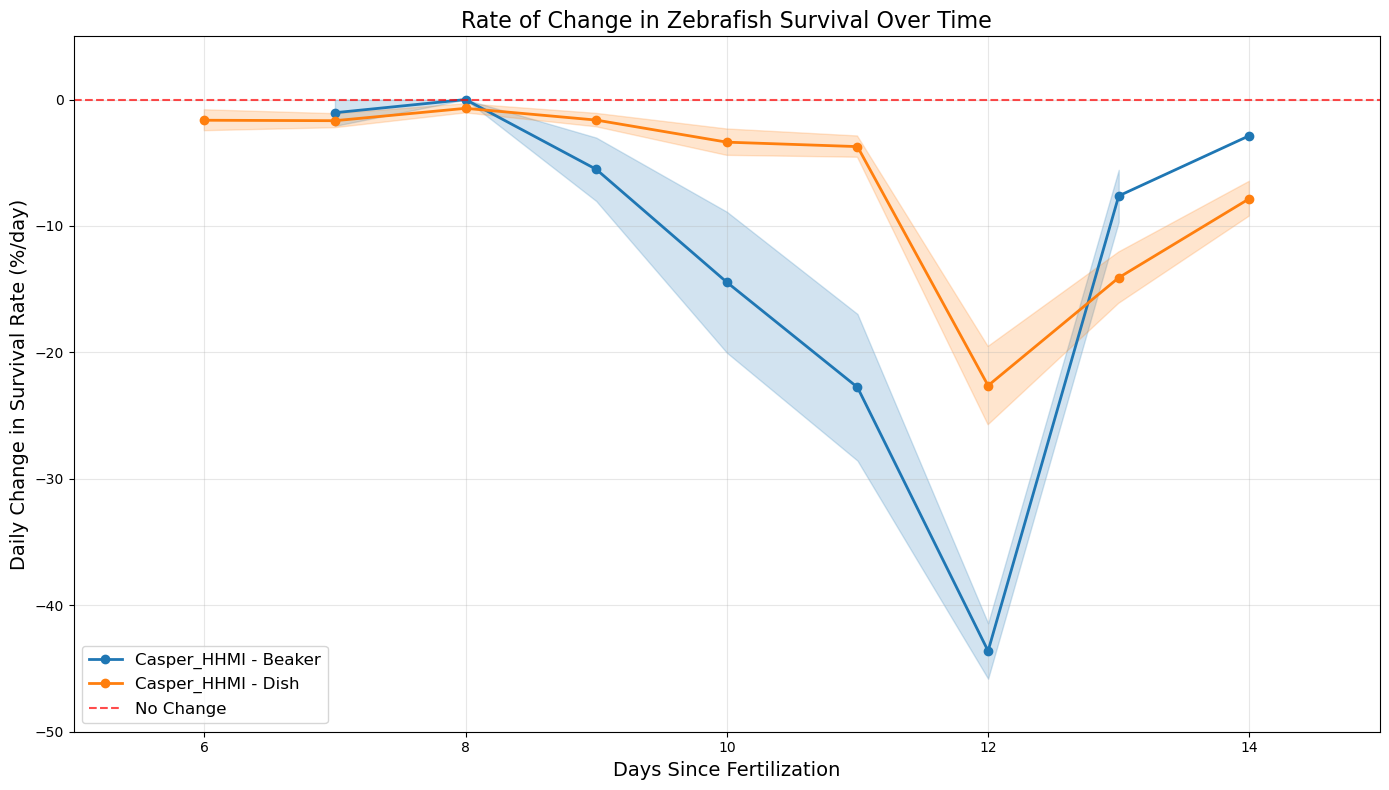

In [221]:
# Load the data
df = pd.read_csv('derivatives.csv')

# Create proper housing type category
df['housing_type_cat'] = df['in_beaker'].replace({'No': 'Dish', 'Yes': 'Beaker'})

df.head()

# Set up the plot with more appropriate dimensions
plt.figure(figsize=(14, 8))

# Plot by housing type and genotype
for (housing, genotype), group in df.groupby(['housing_type_cat', 'genotype']):
    # Skip if no data available
    if group['survival_rate_change'].notna().sum() == 0:
        continue
        
    # Group by day and calculate mean and standard error
    daily_data = group.groupby('days_since_fertilization')['survival_rate_change'].agg(['mean', 'std', 'count']).reset_index()
    daily_data['se'] = daily_data['std'] / np.sqrt(daily_data['count'])
    
    # Plot the line with a label
    line, = plt.plot(daily_data['days_since_fertilization'], 
                     daily_data['mean'],
                     marker='o', 
                     linewidth=2,
                     label=f'{genotype} - {housing}')
    
    # Add error bands
    plt.fill_between(daily_data['days_since_fertilization'],
                     daily_data['mean'] - daily_data['se'],
                     daily_data['mean'] + daily_data['se'],
                     alpha=0.2,
                     color=line.get_color())

# Add reference line at y=0
plt.axhline(y=0, color='r', linestyle='--', alpha=0.7, label='No Change')

# Find the day with the steepest decline
min_idx = df.groupby('days_since_fertilization')['survival_rate_change'].mean().idxmin()
min_value = df.groupby('days_since_fertilization')['survival_rate_change'].mean().min()

# Improve the aesthetics
plt.xlabel('Days Since Fertilization', fontsize=14)
plt.ylabel('Daily Change in Survival Rate (%/day)', fontsize=14)
plt.title('Rate of Change in Zebrafish Survival Over Time', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
# Set axis limits
plt.xlim(5, 15)
plt.ylim(-50, 5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_49435/1834348697.py:27: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_49435/1834348697.py:54: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



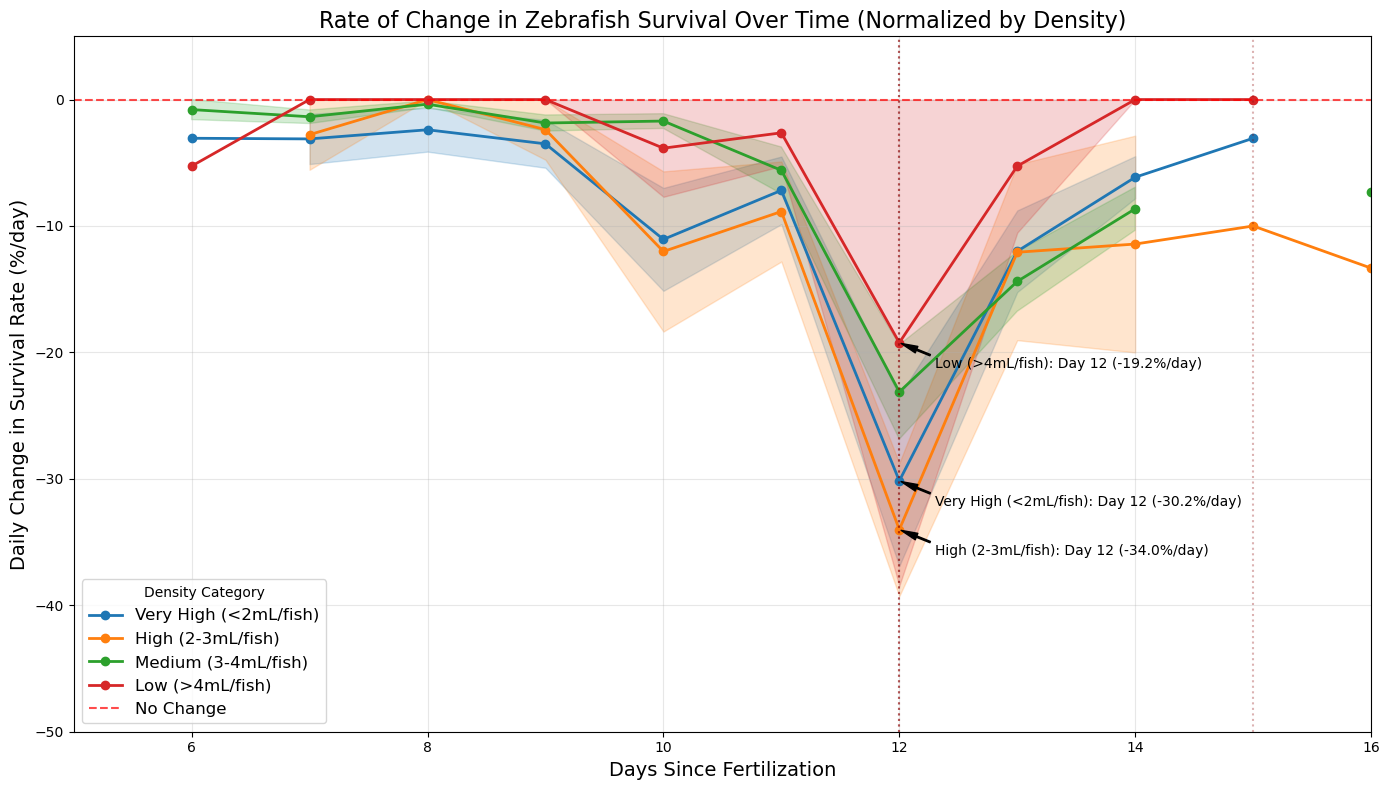

Statistical analysis of critical periods by density category:
                      critical_day                 max_decline             \
                              mean       std count        mean        std   
density_category                                                            
Very High (<2mL/fish)    11.714286  0.755929     7  -30.872615  17.118267   
High (2-3mL/fish)        12.250000  0.500000     4  -36.792891   5.797819   
Medium (3-4mL/fish)      12.464286  1.035737    28        -inf        NaN   
Low (>4mL/fish)          12.500000  0.707107     2  -24.493927  19.753185   

                             
                      count  
density_category             
Very High (<2mL/fish)     7  
High (2-3mL/fish)         4  
Medium (3-4mL/fish)      28  
Low (>4mL/fish)           2  


/tmp/ipykernel_49435/1834348697.py:90: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_49435/1834348697.py:90: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_49435/1834348697.py:98: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('derivatives.csv')

# Create proper housing type category
df['housing_type_cat'] = df['in_beaker'].replace({'No': 'Dish', 'Yes': 'Beaker'})

# Calculate density metrics
df['fish_per_ml'] = df['initial_count'] / df['vol_water_total']
df['volume_per_fish'] = df['vol_water_total'] / df['initial_count']

# Create density categories for easier visualization
df['density_category'] = pd.cut(
    df['volume_per_fish'], 
    bins=[0, 2, 3, 4, np.inf], 
    labels=['Very High (<2mL/fish)', 'High (2-3mL/fish)', 'Medium (3-4mL/fish)', 'Low (>4mL/fish)']
)

# Set up the plot
plt.figure(figsize=(14, 8))

# Plot by density category
for density, group in df.groupby('density_category'):
    # Skip if no data available
    if group['survival_rate_change'].notna().sum() == 0 or len(group) < 3:
        continue
        
    # Group by day and calculate mean and standard error
    daily_data = group.groupby('days_since_fertilization')['survival_rate_change'].agg(['mean', 'std', 'count']).reset_index()
    daily_data['se'] = daily_data['std'] / np.sqrt(daily_data['count'])
    
    # Plot the line with a label
    line, = plt.plot(daily_data['days_since_fertilization'], 
                    daily_data['mean'],
                    marker='o', 
                    linewidth=2,
                    label=f'{density}')
    
    # Add error bands
    plt.fill_between(daily_data['days_since_fertilization'],
                    daily_data['mean'] - daily_data['se'],
                    daily_data['mean'] + daily_data['se'],
                    alpha=0.2,
                    color=line.get_color())

# Add reference line at y=0
plt.axhline(y=0, color='r', linestyle='--', alpha=0.7, label='No Change')

# Find the day with the steepest decline for each density category
for density, group in df.groupby('density_category'):
    if group['survival_rate_change'].notna().sum() == 0 or len(group) < 3:
        continue
        
    # Get the day with the steepest decline
    daily_means = group.groupby('days_since_fertilization')['survival_rate_change'].mean()
    if len(daily_means) > 0:
        critical_day = daily_means.idxmin()
        critical_value = daily_means.min()
        
        # Add vertical line for critical day
        plt.axvline(x=critical_day, color='darkred', linestyle=':', alpha=0.3)
        
        # Add annotation
        plt.annotate(f'{density}: Day {critical_day} ({critical_value:.1f}%/day)',
                    xy=(critical_day, critical_value),
                    xytext=(critical_day+0.3, critical_value-2),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                    fontsize=10)

# Improve the aesthetics
plt.xlabel('Days Since Fertilization', fontsize=14)
plt.ylabel('Daily Change in Survival Rate (%/day)', fontsize=14)
plt.title('Rate of Change in Zebrafish Survival Over Time (Normalized by Density)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, title='Density Category')

# Set axis limits appropriately
plt.xlim(5, 16)
plt.ylim(-50, 5)

plt.tight_layout()
plt.show()

# Statistical analysis
print("Statistical analysis of critical periods by density category:")
critical_periods = df.groupby(['dish_id', 'density_category']).apply(
    lambda x: pd.Series({
        'critical_day': x['days_since_fertilization'][x['survival_rate_change'].idxmin()] if x['survival_rate_change'].notna().any() else np.nan,
        'max_decline': x['survival_rate_change'].min() if x['survival_rate_change'].notna().any() else np.nan
    })
).reset_index()

# Calculate mean critical day and max decline for each density category
density_stats = critical_periods.groupby('density_category')[['critical_day', 'max_decline']].agg(['mean', 'std', 'count'])
print(density_stats)

/tmp/ipykernel_49435/2233792487.py:27: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



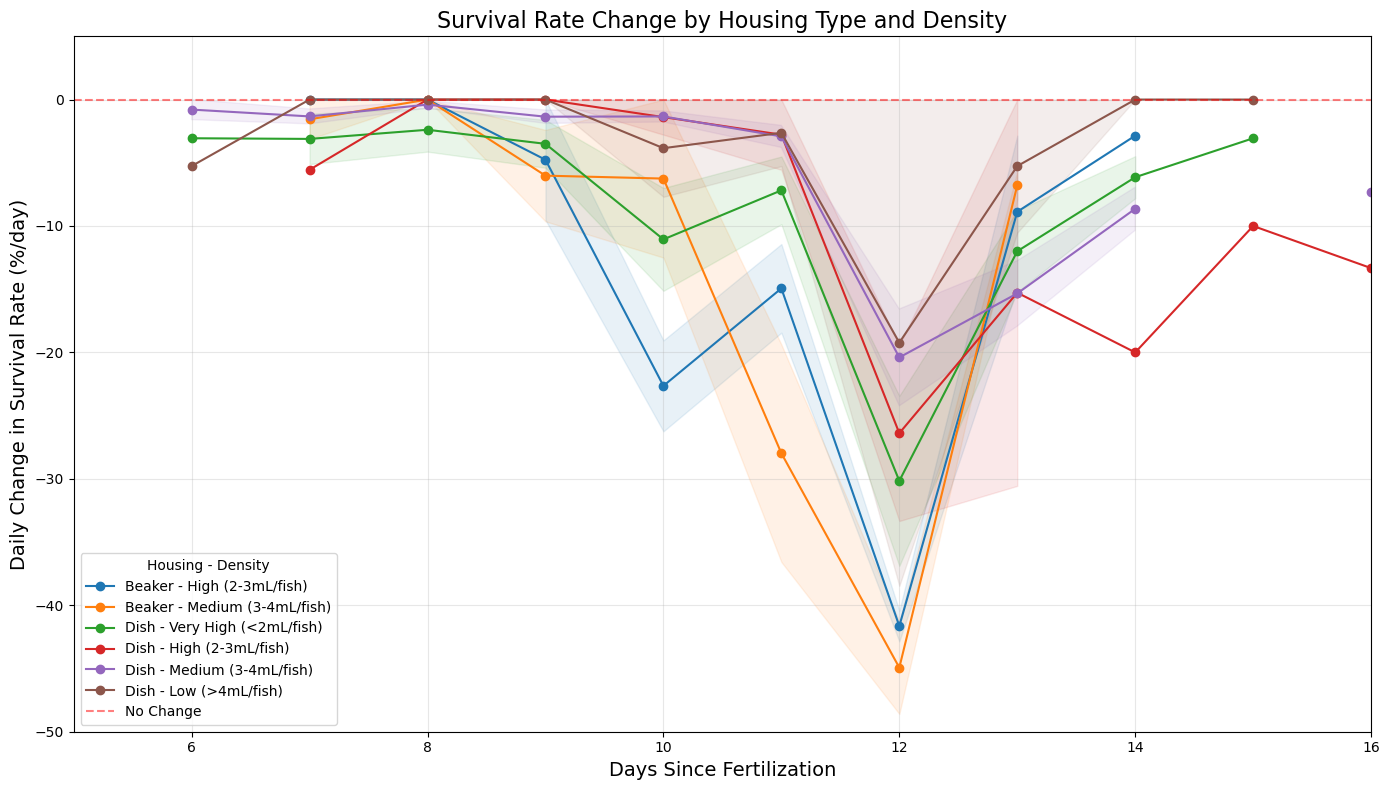

In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('derivatives.csv')

# Create proper housing type category with clear labels
df['housing_type_cat'] = df['in_beaker'].replace({'No': 'Dish', 'Yes': 'Beaker'})

# Calculate density metrics
df['fish_per_ml'] = df['initial_count'] / df['vol_water_total']
df['volume_per_fish'] = df['vol_water_total'] / df['initial_count']

# Create density categories for easier visualization
df['density_category'] = pd.cut(
    df['volume_per_fish'], 
    bins=[0, 2, 3, 4, np.inf], 
    labels=['Very High (<2mL/fish)', 'High (2-3mL/fish)', 'Medium (3-4mL/fish)', 'Low (>4mL/fish)']
)

# Plot by housing type and density combination
plt.figure(figsize=(14, 8))

# Group by housing type and density
for (housing, density), group in df.groupby(['housing_type_cat', 'density_category']):
    # Skip groups with insufficient data
    if group['survival_rate_change'].notna().sum() < 3:
        continue
        
    # Group by day and calculate mean and standard error
    daily_data = group.groupby('days_since_fertilization')['survival_rate_change'].agg(['mean', 'std', 'count']).reset_index()
    daily_data['se'] = daily_data['std'] / np.sqrt(daily_data['count'])
    
    # Create label with clear housing type (beaker/dish)
    label = f"{housing} - {density}"
    
    # Plot the line
    line, = plt.plot(daily_data['days_since_fertilization'], 
                    daily_data['mean'],
                    marker='o', 
                    linewidth=1.5,
                    label=label)
    
    # Add error bands
    plt.fill_between(daily_data['days_since_fertilization'],
                    daily_data['mean'] - daily_data['se'],
                    daily_data['mean'] + daily_data['se'],
                    alpha=0.1,
                    color=line.get_color())

# Add reference line at y=0
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='No Change')

plt.xlabel('Days Since Fertilization', fontsize=14)
plt.ylabel('Daily Change in Survival Rate (%/day)', fontsize=14)
plt.title('Survival Rate Change by Housing Type and Density', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, title='Housing - Density')
plt.xlim(5, 16)
plt.ylim(-50, 5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_49435/1261289063.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



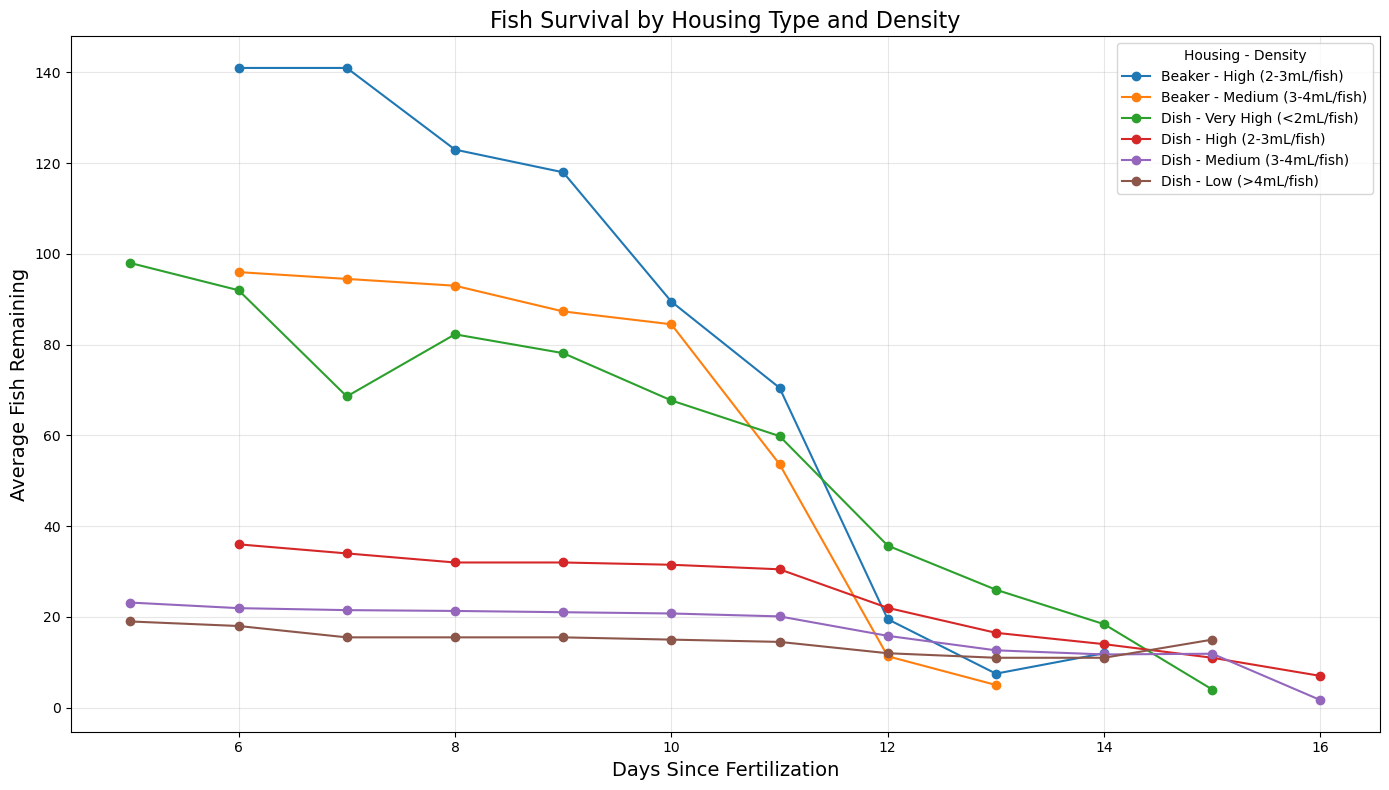

In [224]:
plt.figure(figsize=(14, 8))
for (housing, density), group in df.groupby(['housing_type_cat', 'density_category']):
    if len(group) < 5:  # Skip groups with insufficient data
        continue
    
    # Group by day and calculate mean fish count
    daily_data = group.groupby('days_since_fertilization')['remaining'].mean().reset_index()
    
    # Plot the line
    plt.plot(daily_data['days_since_fertilization'], 
             daily_data['remaining'],
             marker='o', 
             linewidth=1.5,
             label=f"{housing} - {density}")

plt.xlabel('Days Since Fertilization', fontsize=14)
plt.ylabel('Average Fish Remaining', fontsize=14)
plt.title('Fish Survival by Housing Type and Density', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, title='Housing - Density')
plt.tight_layout()

/tmp/ipykernel_49435/2819053507.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



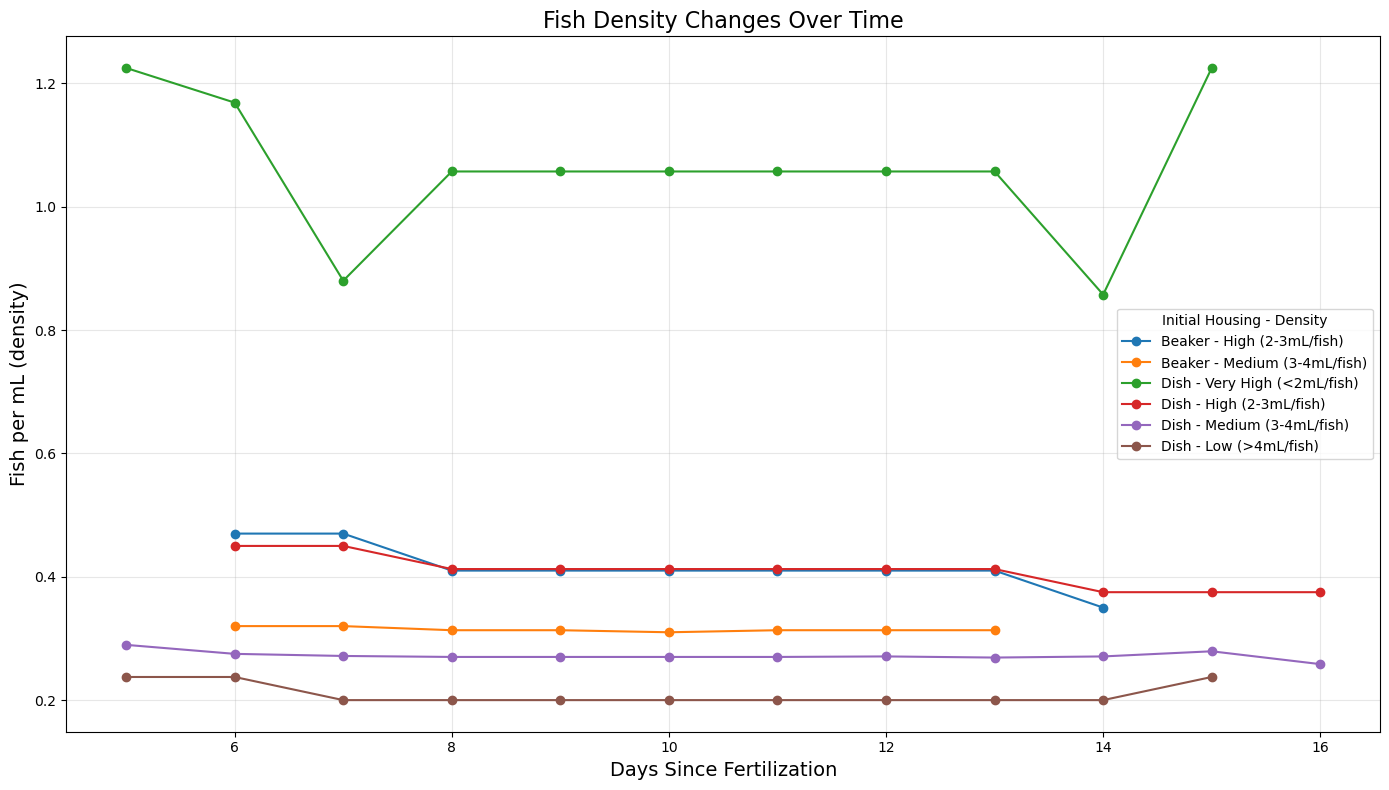

In [228]:
plt.figure(figsize=(14, 8))
for (housing, density), group in df.groupby(['housing_type_cat', 'density_category']):
    if len(group) < 5:  # Skip groups with insufficient data
        continue
    
    # Group by day and calculate mean density
    daily_data = group.groupby('days_since_fertilization')['fish_per_ml'].mean().reset_index()
    
    # Plot the line
    plt.plot(daily_data['days_since_fertilization'], 
             daily_data['fish_per_ml'],
             marker='o', 
             linewidth=1.5,
             label=f"{housing} - {density}")

plt.xlabel('Days Since Fertilization', fontsize=14)
plt.ylabel('Fish per mL (density)', fontsize=14)
plt.title('Fish Density Changes Over Time', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, title='Initial Housing - Density')
plt.tight_layout()

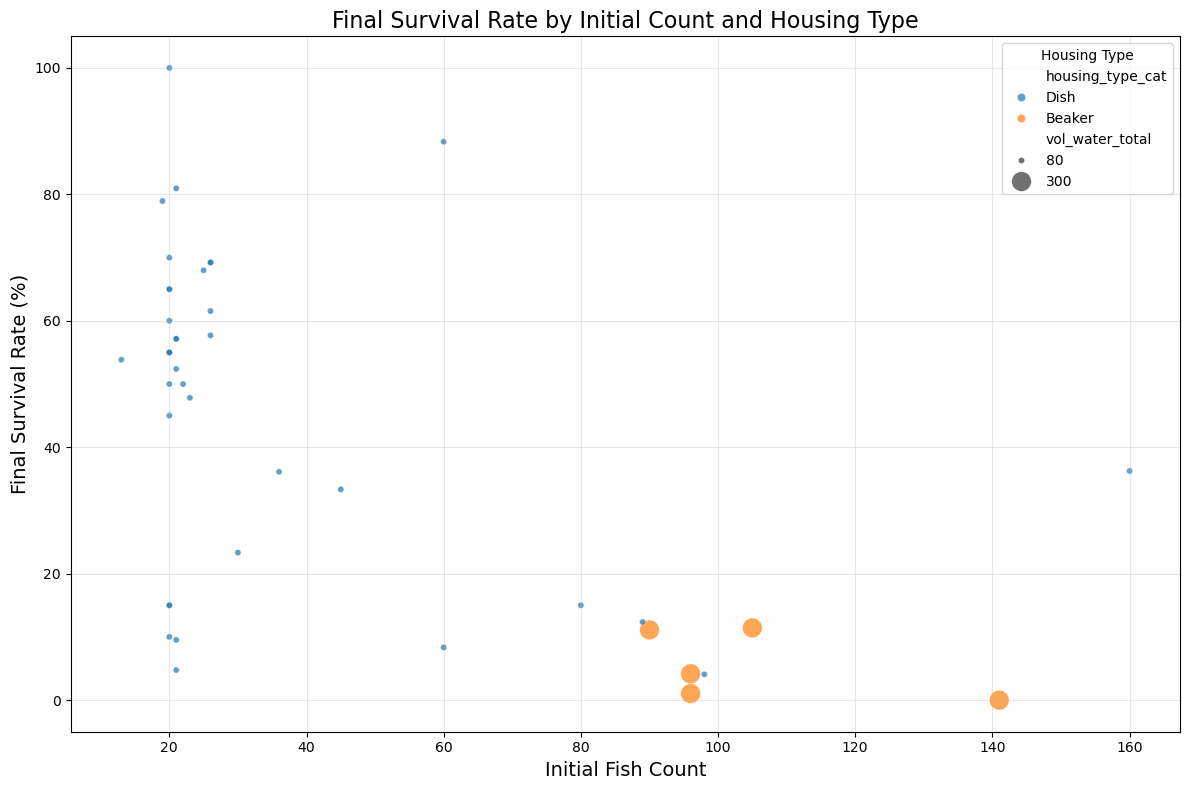

In [226]:
# Filter for only the last observation of each dish
last_observations = df.sort_values('days_since_fertilization').groupby('dish_id').last().reset_index()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=last_observations, 
                x='initial_count',
                y='survival_rate', 
                hue='housing_type_cat',
                size='vol_water_total',
                sizes=(20, 200),
                alpha=0.7)

plt.xlabel('Initial Fish Count', fontsize=14)
plt.ylabel('Final Survival Rate (%)', fontsize=14)
plt.title('Final Survival Rate by Initial Count and Housing Type', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(title='Housing Type')
plt.tight_layout()

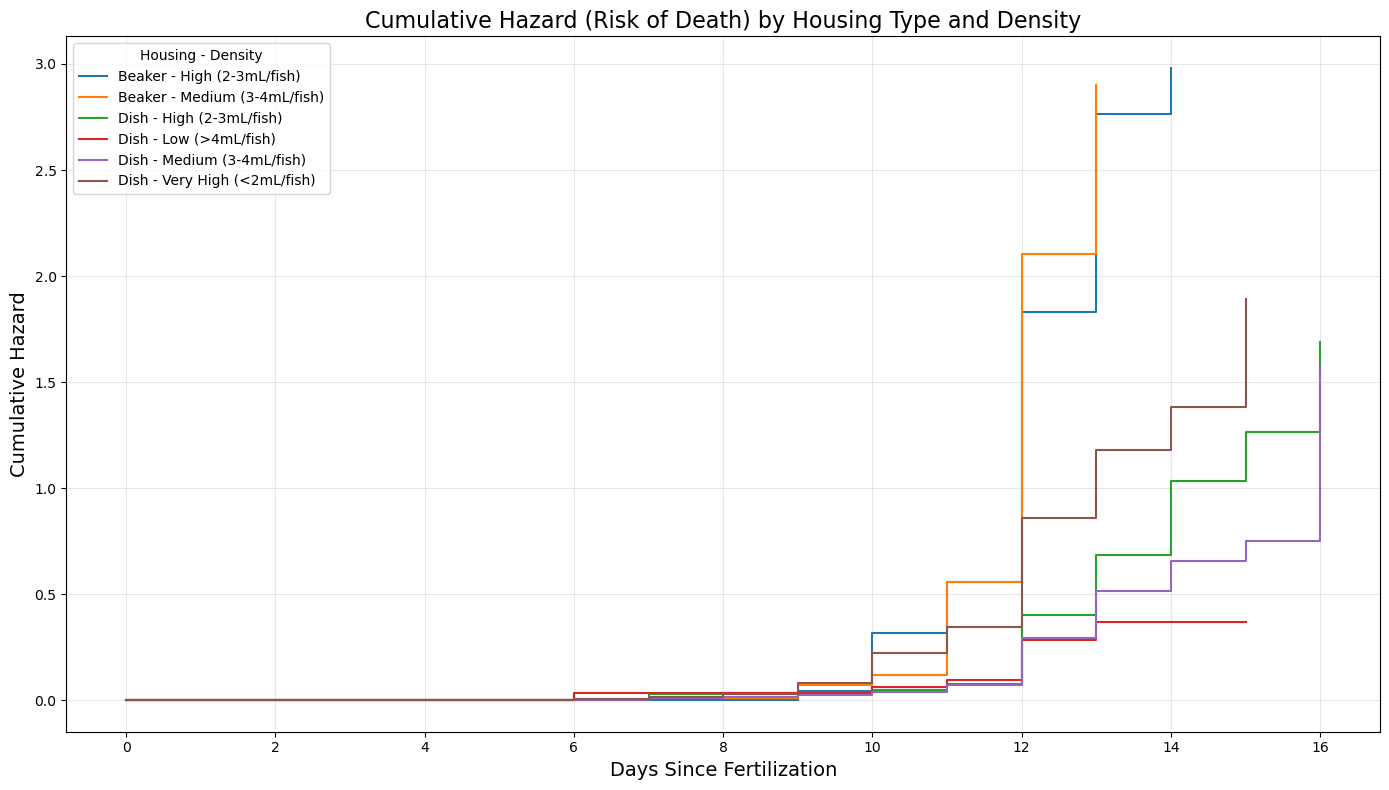

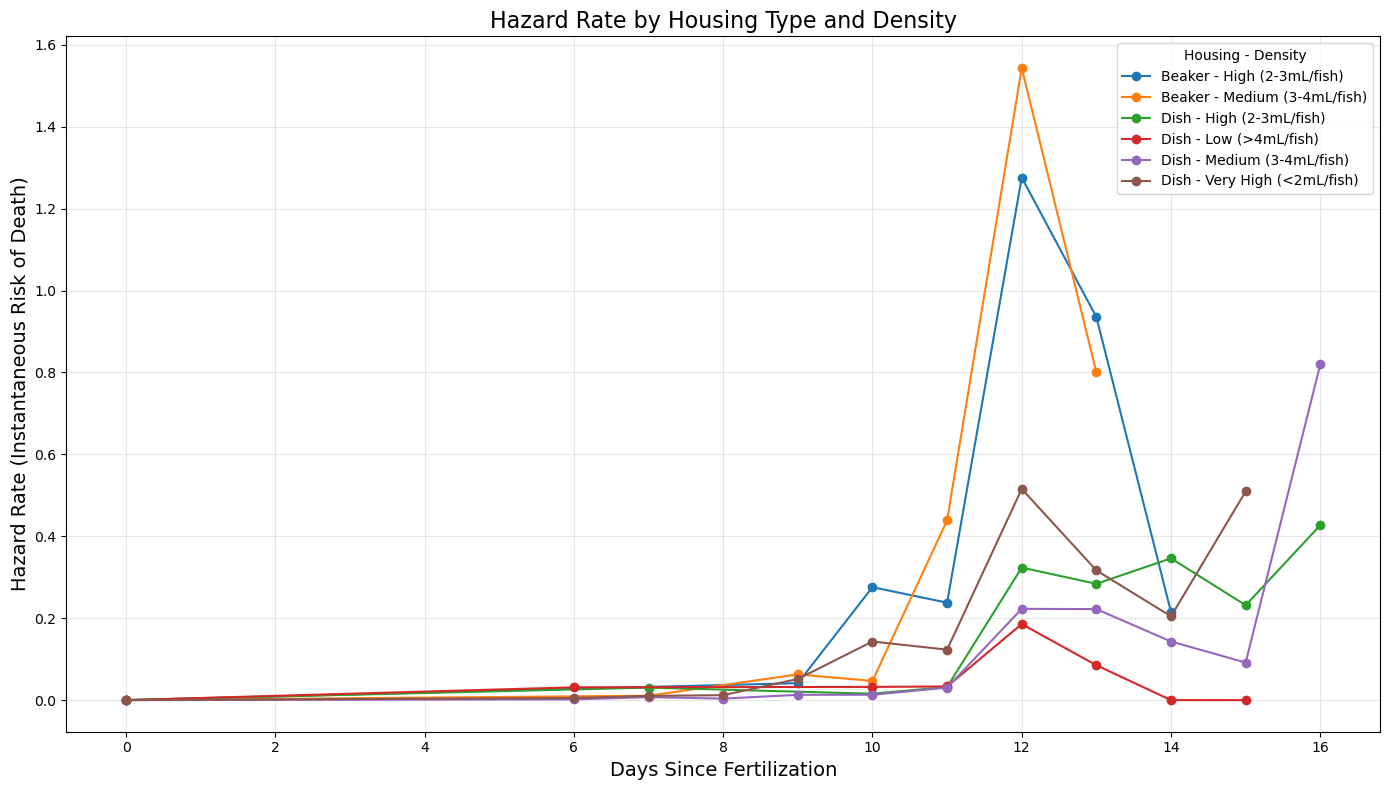

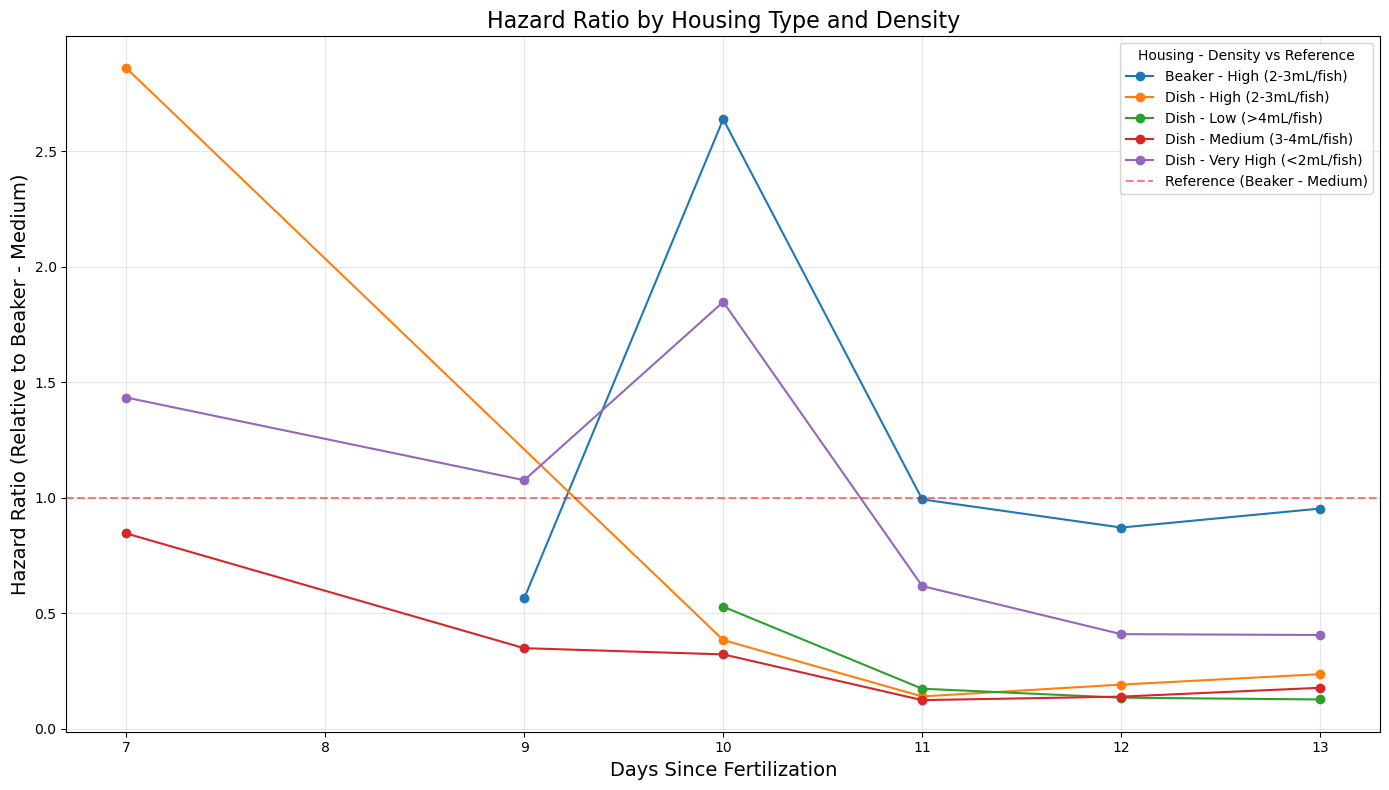

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, NelsonAalenFitter

# Load the data
df = pd.read_csv('derivatives.csv')

# Create proper housing type category with clear labels
df['housing_type_cat'] = df['in_beaker'].replace({'No': 'Dish', 'Yes': 'Beaker'})

# Prepare the data for survival analysis
# We'll create a long-format dataframe where each row represents a fish
# We need to reconstruct deaths at each time point

survival_data = []

# Group by dish_id to track individual dishes over time
for dish_id, dish_data in df.groupby('dish_id'):
    # Sort by days since fertilization
    dish_data = dish_data.sort_values('days_since_fertilization')
    
    # Get metadata from the first row
    genotype = dish_data['genotype'].iloc[0]
    housing_type = dish_data['housing_type_cat'].iloc[0]
    density_category = dish_data['density_category'].iloc[0]
    
    # Get the initial count
    initial_count = dish_data['initial_count'].iloc[0]
    
    # Track the previously observed cumulative deaths
    prev_cum_deaths = 0
    
    # For each time point
    for _, row in dish_data.iterrows():
        days = row['days_since_fertilization']
        cum_deaths = row['cumulative_deaths']
        
        # Calculate new deaths in this period
        new_deaths = cum_deaths - prev_cum_deaths
        
        # Record each death
        for i in range(int(new_deaths)):
            survival_data.append({
                'dish_id': dish_id,
                'genotype': genotype,
                'housing_type': housing_type,
                'density_category': density_category,
                'time': days,
                'event': 1  # 1 indicates death occurred
            })
        
        # Record censored (survived) observations at the last time point
        if days == dish_data['days_since_fertilization'].max():
            remaining = row['remaining']
            for i in range(int(remaining)):
                survival_data.append({
                    'dish_id': dish_id,
                    'genotype': genotype,
                    'housing_type': housing_type,
                    'density_category': density_category,
                    'time': days,
                    'event': 0  # 0 indicates censoring (still alive)
                })
        
        # Update previously observed cumulative deaths
        prev_cum_deaths = cum_deaths

# Create a dataframe from the survival data
survival_df = pd.DataFrame(survival_data)

# Calculate hazard rates using Nelson-Aalen estimator
plt.figure(figsize=(14, 8))

# Group by housing type and density
for (housing, density), group in survival_df.groupby(['housing_type', 'density_category']):
    # Skip groups with insufficient data
    if len(group) < 10:
        continue
    
    # Fit Nelson-Aalen model
    naf = NelsonAalenFitter()
    naf.fit(group['time'], group['event'], label=f"{housing} - {density}")
    
    # Plot the cumulative hazard
    naf.plot_cumulative_hazard(ci_show=False)

plt.xlabel('Days Since Fertilization', fontsize=14)
plt.ylabel('Cumulative Hazard', fontsize=14)
plt.title('Cumulative Hazard (Risk of Death) by Housing Type and Density', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, title='Housing - Density')
plt.tight_layout()

# Now let's calculate the hazard rate (first derivative of cumulative hazard)
plt.figure(figsize=(14, 8))

# Group by housing type and density
for (housing, density), group in survival_df.groupby(['housing_type', 'density_category']):
    # Skip groups with insufficient data
    if len(group) < 10:
        continue
    
    # Fit Nelson-Aalen model
    naf = NelsonAalenFitter()
    naf.fit(group['time'], group['event'])
    
    # Get the cumulative hazard
    cum_hazard = naf.cumulative_hazard_
    
    # Calculate the hazard rate (take the derivative)
    cum_hazard = cum_hazard.sort_index()
    hazard_rate = cum_hazard.diff()
    hazard_rate = hazard_rate.fillna(0)
    
    # Plot the hazard rate
    plt.plot(hazard_rate.index, hazard_rate.iloc[:, 0], 
             marker='o', linewidth=1.5, 
             label=f"{housing} - {density}")

plt.xlabel('Days Since Fertilization', fontsize=14)
plt.ylabel('Hazard Rate (Instantaneous Risk of Death)', fontsize=14)
plt.title('Hazard Rate by Housing Type and Density', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, title='Housing - Density')
plt.tight_layout()

# We can also analyze the hazard ratios between different housing types
# by calculating their relative hazards

plt.figure(figsize=(14, 8))

# Use Beaker - Medium as reference
reference_group = survival_df[(survival_df['housing_type'] == 'Beaker') & 
                             (survival_df['density_category'] == 'Medium (3-4mL/fish)')]

if len(reference_group) >= 10:
    # Fit reference group
    ref_naf = NelsonAalenFitter()
    ref_naf.fit(reference_group['time'], reference_group['event'])
    
    # Get reference cumulative hazard
    ref_cum_hazard = ref_naf.cumulative_hazard_
    
    # Compare other groups to reference
    for (housing, density), group in survival_df.groupby(['housing_type', 'density_category']):
        # Skip reference group and groups with insufficient data
        if housing == 'Beaker' and density == 'Medium (3-4mL/fish)' or len(group) < 10:
            continue
        
        # Fit current group
        curr_naf = NelsonAalenFitter()
        curr_naf.fit(group['time'], group['event'])
        
        # Get current cumulative hazard
        curr_cum_hazard = curr_naf.cumulative_hazard_
        
        # Calculate hazard ratio at each time point
        # Merge the two cumulative hazards
        merged = pd.merge(curr_cum_hazard, ref_cum_hazard, 
                         left_index=True, right_index=True, 
                         how='inner', suffixes=('_curr', '_ref'))
        
        # Calculate the ratio
        merged['ratio'] = merged.iloc[:, 0] / merged.iloc[:, 1]
        
        # Plot the hazard ratio
        plt.plot(merged.index, merged['ratio'], 
                marker='o', linewidth=1.5, 
                label=f"{housing} - {density}")

    plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Reference (Beaker - Medium)')
    plt.xlabel('Days Since Fertilization', fontsize=14)
    plt.ylabel('Hazard Ratio (Relative to Beaker - Medium)', fontsize=14)
    plt.title('Hazard Ratio by Housing Type and Density', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10, title='Housing - Density vs Reference')
    plt.tight_layout()

In [5]:
def fix_date_representations(df):
    """
    Fix the date representations in the dataset
    """
    print("Fixing date representations...")
    
    # Make a copy of the dataframe
    fixed_df = df.copy()
    
    # Check which date columns we have in string format
    date_string_cols = [col for col in fixed_df.columns if '_dt' in col and fixed_df[col].dtype == 'object']
    
    # Convert string date columns to proper datetime
    for col in date_string_cols:
        try:
            fixed_df[col] = pd.to_datetime(fixed_df[col])
            # Get the base column name (without _dt)
            base_col = col.replace('_dt', '')
            # If the base column exists, replace it with the datetime version
            if base_col in fixed_df.columns:
                fixed_df[base_col] = fixed_df[col]
        except Exception as e:
            print(f"Could not convert {col}: {e}")
    
    # Calculate days_since_fertilization correctly using actual dates
    if 'date_fertilized' in fixed_df.columns and 'check_date' in fixed_df.columns:
        if pd.api.types.is_datetime64_any_dtype(fixed_df['date_fertilized']) and pd.api.types.is_datetime64_any_dtype(fixed_df['check_date']):
            fixed_df['days_since_fertilization'] = (fixed_df['check_date'] - fixed_df['date_fertilized']).dt.days
    
    # Fix the plot_forecast function to display dates correctly
    print("Note: You'll also need to update the plot_forecast function to display dates correctly")
    
    print(f"Fixed date format. Sample dates:")
    for col in date_string_cols:
        if col in fixed_df.columns:
            print(f"{col}: {fixed_df[col].iloc[0]}")
    
    return fixed_df

In [136]:
def statistical_analysis(df):
    """Perform statistical analysis on factors affecting survival"""
    import statsmodels.api as sm
    from statsmodels.formula.api import ols
    import scipy.stats as stats
    
    results = {}
    
    # Check which factors we have available
    categorical_factors = ['genotype', 'room', 'in_beaker', 'water_changed', 'responsible']
    available_factors = [f for f in categorical_factors if f in df.columns]
    
    # One-way ANOVA for each categorical factor
    for factor in available_factors:
        if df[factor].nunique() < 2:
            results[factor] = "Insufficient variation for analysis"
            continue
            
        try:
            # Fit OLS model
            model = ols(f'survival_rate ~ C({factor})', data=df).fit()
            
            # Perform ANOVA
            anova_table = sm.stats.anova_lm(model, typ=2)
            
            # Store results
            results[factor] = {
                'p_value': anova_table['PR(>F)'][0],
                'f_value': anova_table['F'][0],
                'significant': anova_table['PR(>F)'][0] < 0.05
            }
        except Exception as e:
            results[factor] = f"Analysis failed: {str(e)}"
    
    # Create a summary table
    summary_rows = []
    for factor, result in results.items():
        if isinstance(result, dict):
            summary_rows.append({
                'Factor': factor,
                'F-value': f"{result['f_value']:.2f}",
                'p-value': f"{result['p_value']:.4f}",
                'Significant': "Yes" if result['significant'] else "No"
            })
        else:
            summary_rows.append({
                'Factor': factor,
                'F-value': "N/A",
                'p-value': "N/A",
                'Significant': result
            })
    
    summary_df = pd.DataFrame(summary_rows)
    
    # Additional analysis: correlation between days and survival rate
    if 'days_since_fertilization' in df.columns:
        corr, p_value = stats.pearsonr(
            df['days_since_fertilization'].dropna(),
            df['survival_rate'].dropna()
        )
        
        summary_rows.append({
            'Factor': 'Days since fertilization (correlation)',
            'F-value': "N/A",
            'p-value': f"{p_value:.4f}",
            'Significant': "Yes" if p_value < 0.05 else "No"
        })
        
        print(f"Correlation between days and survival: r = {corr:.2f}, p = {p_value:.4f}")
    
    return summary_df

# Perform statistical analysis
statistical_analysis(df)

Correlation between days and survival: r = -0.73, p = 0.0000


/tmp/ipykernel_49435/2678688220.py:28: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_49435/2678688220.py:29: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_49435/2678688220.py:30: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



,Factor,F-value,p-value,Significant
0,genotype,N/A,N/A,Insufficient variation for analysis
1,room,N/A,N/A,Insufficient variation for analysis
2,in_beaker,13.64,0.0003,Yes
3,water_changed,N/A,N/A,Insufficient variation for analysis
4,responsible,N/A,N/A,Insufficient variation for analysis
